Objectives:
- Understand and define AgentState structure
- Create simple node functions to process and update state
- Set up basic LangGraph structure
- Compile and invoke a LangGraph graph
- Understand how data flows througha single-node in LangGraph

In [2]:
from typing import Dict,TypedDict
#Manages nodes, edges & overall state 
from langgraph.graph import StateGraph

In [9]:
#create an AgentState - shared data structure that keeps track of information as the appln runs
class AgentState(TypedDict):
    message: str

#input the AgentState and output the updated AgentState
def greeting_node(state: AgentState) -> AgentState:
    """Simple Node that adds a greeting message to the state"""

    state['message'] = "Hello " + state["message"] + "! How is your day going"

    return state


In [10]:
graph=StateGraph(AgentState)

graph.add_node("GreetingNode",greeting_node)

graph.set_entry_point("GreetingNode")
graph.set_finish_point("GreetingNode")

app=graph.compile()

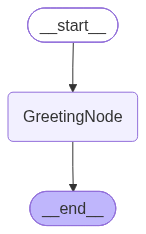

In [6]:
from IPython.display import Image,display

display(Image(app.get_graph().draw_mermaid_png()))

In [11]:
result=app.invoke({"message":"Priya"})

In [12]:
result["message"]

'Hello Priya! How is your day going'

Exercise:

- Create a Personalised Compliment Agent

In [13]:
class ComplimentAgentState(TypedDict):
    name: str
    streak: int
    compliment: str

def ComplimentFunction(state: ComplimentAgentState) -> ComplimentAgentState:
    """Simple node that compliments user based on learning streak"""

    name=state["name"]
    streak=state["streak"]

    if streak >= 30:
        state["compliment"] = f"Amazing, {name}! A {streak}-day streak is incredible. You're extremely consistent!"
    elif streak >= 14:
        state["compliment"] = f"Great job, {name}! {streak} days of learning is fantastic consistency!"
    elif streak >= 7:
        state["compliment"] = f"Well done, {name}! You've kept your learning streak going for {streak} days!"
    else:
        state["compliment"] = f"Nice start, {name}! You've already learned for {streak} days. Keep going!"

    return state


In [14]:
ComplimentGraph=StateGraph(ComplimentAgentState)

ComplimentGraph.add_node("ComplimentNode",ComplimentFunction)
ComplimentGraph.set_entry_point("ComplimentNode")
ComplimentGraph.set_finish_point("ComplimentNode")

app=ComplimentGraph.compile()


In [15]:
compliment=app.invoke({"name":"Priya","streak":25,"compliment":""})
print(compliment)

{'name': 'Priya', 'streak': 25, 'compliment': 'Great job, Priya! 25 days of learning is fantastic consistency!'}


MULTIPLE INPUT GRAPH

In [1]:
from typing import TypedDict,List
from langgraph.graph import StateGraph

In [9]:
class AgentState(TypedDict):
    values: List[int]
    name: str
    result: str

In [16]:
def process_values(state: AgentState)->AgentState:
    """"Processes multiple inputs"""

    state['result']=f"Hi there {state['name']}! Your sum is= {sum(state["values"])}"
    return state
    

In [18]:
graph=StateGraph(AgentState)
graph.add_node('ProcessValues',process_values)
graph.set_entry_point('ProcessValues')
graph.set_finish_point('ProcessValues')

app=graph.compile()

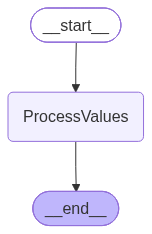

In [19]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [20]:
answer=app.invoke({"values":[1,2,3,4],"name":"Rahul"})


In [21]:
print(answer['result'])

Hi there Rahul! Your sum is= 10


EXERCISE

Graph's input should be a name, a list of integers and an operand. Based on operand return the correct answer

In [49]:
from typing import TypedDict,List
from langgraph.graph import StateGraph
import math

class AgentState(TypedDict):
    name:str
    values:List[int]
    operand:str
    answer:str

In [50]:
def performOperation(state: AgentState)->AgentState:
    """Perform specified operation on given list"""
    
    if state['operand']=="+":
        state['answer']=(f"This is {state['name']}. My value is {sum(state['values'])}")
    elif state['operand']=="*":
        state['answer']=(f"This is {state['name']}. My value is {math.prod(state['values'])}")

    return state


In [51]:
graph=StateGraph(AgentState)
graph.add_node("Operation",performOperation)
graph.set_entry_point("Operation")
graph.set_finish_point("Operation")

app=graph.compile()

In [52]:
result=app.invoke({
    'name':"Keerthana",
    'values':[1,2,3,4],
    'operand':"*"
})


In [53]:
print(result)

{'name': 'Keerthana', 'values': [1, 2, 3, 4], 'operand': '*', 'answer': 'This is Keerthana. My value is 24'}
